# Chapter 15 — Turning Bigram Counts Into Probabilities

Chapter 14 represented adjacent-character counts as a table whose rows were previous tokens and whose columns were next tokens.

This chapter normalizes those count rows into conditional probability distributions that can drive sampling and generation.

By the end of this chapter, you should be able to:

- explain why generation needs probabilities;
- normalize one count row;
- convert a full count table into a probability table;
- validate every probability row;
- interpret each cell as $P(\text{next token}\mid\text{previous token})$;
- identify and handle a zero row deliberately;
- distinguish fallback from smoothing;
- sample and generate from probability rows; and
- explain why the resulting model still uses only local context.

This chapter completes the unsmoothed count-based bigram model without introducing neural networks.


## Normalize Counts Within Each Condition

A count records how many times an event appeared in the training data.

Generation instead needs a probability distribution that says how sampling weight should be divided among possible next tokens.

Suppose `"a"` followed `"c"` three times and `"k"` followed `"c"` once.

The row total is four, so the estimated probabilities are $3/4$ and $1/4$.

Dividing every count in one row by that row's total is called **row normalization**.


## Conditional Probability

Each normalized row is a separate probability distribution under one condition.

The expression $P(\text{next}=\text{"a"}\mid\text{previous}=\text{"c"})$ means the probability of `"a"` given that the previous character is `"c"`.

The table orientation remains `probability_table[previous_token_id][next_token_id]`.


## Reuse the Prepared Fixture

Using the same fixture as Chapters 13 and 14 isolates the effect of normalization.


In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print(repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build the Vocabulary and IDs

Token IDs index both the count table and the probability table.


In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)
vocabulary_size = len(character_vocabulary)

print("Vocabulary size:", vocabulary_size)
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>3}: {character!r}")

Vocabulary size: 22
  0: '\n'
  1: ' '
  2: '!'
  3: '.'
  4: 'T'
  5: 'a'
  6: 'b'
  7: 'c'
  8: 'd'
  9: 'e'
 10: 'g'
 11: 'h'
 12: 'i'
 13: 'k'
 14: 'l'
 15: 'n'
 16: 'o'
 17: 'r'
 18: 's'
 19: 't'
 20: 'w'
 21: 'y'


## Encode and Verify the Fixture

The round trip confirms that the IDs preserve the exact training text.


In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


token_ids = encode_characters(prepared_text, character_to_id)
decoded_text = decode_character_ids(token_ids, id_to_character)

assert decoded_text == prepared_text
print("Token count:", len(token_ids))
print("First 80 token IDs:", token_ids[:80])

Token count: 106
First 80 token IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4, 11, 9, 1, 8, 16, 10, 1, 14, 16, 16, 13, 9, 8, 1, 5, 19, 1, 19, 11, 9]


## Rebuild the Bigram Count Table

Each adjacent token pair adds one to the row for its previous token and the column for its next token.


In [4]:
def create_zero_count_table(vocabulary_size: int) -> list[list[int]]:
    if vocabulary_size < 1:
        raise ValueError("vocabulary_size must be at least 1.")
    return [[0 for _ in range(vocabulary_size)] for _ in range(vocabulary_size)]


def build_bigram_count_table(
    token_ids: list[int],
    vocabulary_size: int,
) -> list[list[int]]:
    if len(token_ids) < 2:
        raise ValueError("token_ids must contain at least two IDs.")

    count_table = create_zero_count_table(vocabulary_size)
    for position, (previous_token_id, next_token_id) in enumerate(
        zip(token_ids[:-1], token_ids[1:], strict=True)
    ):
        if not 0 <= previous_token_id < vocabulary_size:
            raise ValueError(f"Invalid previous token ID at position {position}.")
        if not 0 <= next_token_id < vocabulary_size:
            raise ValueError(f"Invalid next token ID at position {position + 1}.")
        count_table[previous_token_id][next_token_id] += 1
    return count_table


bigram_count_table = build_bigram_count_table(token_ids, vocabulary_size)
print(
    "Count table shape:",
    len(bigram_count_table),
    "rows ×",
    len(bigram_count_table[0]),
    "columns",
)

Count table shape: 22 rows × 22 columns


## Verify the Count Table

A sequence of $N$ tokens contains $N-1$ adjacent pairs.


In [5]:
def sum_count_table(table: list[list[int]]) -> int:
    return sum(sum(row) for row in table)


total_bigram_count = sum_count_table(bigram_count_table)
expected_bigram_count = len(token_ids) - 1

print("Table total:", total_bigram_count)
print("Expected total:", expected_bigram_count)
assert total_bigram_count == expected_bigram_count

Table total: 105
Expected total: 105


## Normalize One Row Manually

The row for `"c"` makes the arithmetic concrete before it is hidden inside a helper.


In [6]:
previous_character = "c"
previous_token_id = character_to_id[previous_character]
count_row_for_c = bigram_count_table[previous_token_id]
row_total_for_c = sum(count_row_for_c)
probability_row_for_c = [count / row_total_for_c for count in count_row_for_c]

print("Count row:", count_row_for_c)
print("Row total:", row_total_for_c)
print("Probability row:", probability_row_for_c)
print("Probability sum:", sum(probability_row_for_c))

Count row: [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0]
Row total: 5
Probability row: [0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0]
Probability sum: 1.0


## Label the Probability Row

The nonzero entries show exactly how the observed counts become sampling probabilities.


In [7]:
print("Next character | Count | Probability")
print("-" * 38)
for next_token_id, probability in enumerate(probability_row_for_c):
    if probability > 0:
        print(
            f"{id_to_character[next_token_id]!r:>14} | "
            f"{count_row_for_c[next_token_id]:>5} | {probability:>11.6f}"
        )

Next character | Count | Probability
--------------------------------------
           'a' |     3 |    0.600000
           'k' |     1 |    0.200000
           'r' |     1 |    0.200000


## Validate Probability Distributions

A valid distribution is nonempty, contains no negative values, and sums to one within a small floating-point tolerance.


In [8]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    probability_sum = sum(probabilities)
    if abs(probability_sum - 1.0) > 1e-12:
        raise ValueError(
            f"Probabilities must sum to 1, but the sum is {probability_sum}."
        )


assert_valid_probability_distribution(probability_row_for_c)
print("The probability row for 'c' is valid.")

The probability row for 'c' is valid.


## Normalize One Reusable Count Row

A row whose total is zero cannot be normalized because division by zero is undefined.


In [9]:
def normalize_count_row(count_row: list[int]) -> list[float]:
    if any(count < 0 for count in count_row):
        raise ValueError("Counts cannot be negative.")

    row_total = sum(count_row)
    if row_total == 0:
        raise ValueError("Cannot normalize a count row whose total is 0.")

    probabilities = [count / row_total for count in count_row]
    assert_valid_probability_distribution(probabilities)
    return probabilities


normalized_row_for_c = normalize_count_row(count_row_for_c)
assert normalized_row_for_c == probability_row_for_c
print("Manual and helper results match:", True)

Manual and helper results match: True


## Expose the Zero-Row Problem

In the toy text `"az"`, `"z"` belongs to the vocabulary but appears only at the final position.

Its count row is therefore all zeros because no token follows it.


In [10]:
toy_text = "az"
toy_vocabulary, toy_character_to_id, toy_id_to_character = build_character_mappings(
    toy_text
)
toy_token_ids = encode_characters(toy_text, toy_character_to_id)
toy_count_table = build_bigram_count_table(toy_token_ids, len(toy_vocabulary))
z_count_row = toy_count_table[toy_character_to_id["z"]]

print("Toy vocabulary:", toy_vocabulary)
print("Toy count table:", toy_count_table)
print("Row for 'z':", z_count_row)

try:
    normalize_count_row(z_count_row)
except ValueError as error:
    print("Caught expected error:", error)

Toy vocabulary: ['a', 'z']
Toy count table: [[0, 1], [0, 0]]
Row for 'z': [0, 0]
Caught expected error: Cannot normalize a count row whose total is 0.


The error is intentional because a zero row contains no evidence from which to estimate relative next-token probabilities.

A model needs an explicit policy for that situation.


## Build a Unigram Fallback

A **fallback distribution** supplies probabilities when no usable bigram row exists.

We will use overall character frequencies, which form the unigram distribution from Chapter 12.

Fallback is not smoothing because it replaces only an unusable row instead of changing probabilities inside observed rows.


In [11]:
def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        if not 0 <= token_id < vocabulary_size:
            raise ValueError(f"Invalid token ID {token_id}.")
        counts[token_id] += 1
    return counts


unigram_counts = count_token_ids(token_ids, vocabulary_size)
unigram_fallback_probabilities = normalize_count_row(unigram_counts)

print("Character | Unigram fallback probability")
print("-" * 42)
for token_id, probability in enumerate(unigram_fallback_probabilities):
    print(f"{id_to_character[token_id]!r:>9} | {probability:.6f}")

Character | Unigram fallback probability
------------------------------------------
     '\n' | 0.037736
      ' ' | 0.169811
      '!' | 0.009434
      '.' | 0.028302
      'T' | 0.037736
      'a' | 0.094340
      'b' | 0.009434
      'c' | 0.047170
      'd' | 0.056604
      'e' | 0.094340
      'g' | 0.018868
      'h' | 0.066038
      'i' | 0.009434
      'k' | 0.028302
      'l' | 0.018868
      'n' | 0.028302
      'o' | 0.075472
      'r' | 0.037736
      's' | 0.028302
      't' | 0.075472
      'w' | 0.018868
      'y' | 0.009434


## Normalize the Entire Table

Observed rows are normalized from their own counts, while zero rows receive a copy of the fallback distribution.

Copying prevents accidental changes to one row from modifying the shared fallback list.


In [12]:
def count_table_to_probability_table(
    count_table: list[list[int]],
    fallback_probabilities: list[float],
) -> tuple[list[list[float]], list[int]]:
    assert_valid_probability_distribution(fallback_probabilities)
    expected_width = len(fallback_probabilities)
    probability_table = []
    fallback_row_ids = []

    for row_id, count_row in enumerate(count_table):
        if len(count_row) != expected_width:
            raise ValueError("Every count row must match the fallback width.")
        if sum(count_row) == 0:
            probability_table.append(fallback_probabilities.copy())
            fallback_row_ids.append(row_id)
        else:
            probability_table.append(normalize_count_row(count_row))
    return probability_table, fallback_row_ids


bigram_probability_table, fallback_row_ids = count_table_to_probability_table(
    bigram_count_table,
    unigram_fallback_probabilities,
)

print(
    "Probability table shape:",
    len(bigram_probability_table),
    "rows ×",
    len(bigram_probability_table[0]),
    "columns",
)
print("Fallback rows:", [id_to_character[row_id] for row_id in fallback_row_ids])

Probability table shape: 22 rows × 22 columns
Fallback rows: []


## Verify Every Probability Row

Every returned row must now be safe to use for sampling.


In [13]:
for probability_row in bigram_probability_table:
    assert_valid_probability_distribution(probability_row)

assert len(bigram_probability_table) == vocabulary_size
assert all(len(row) == vocabulary_size for row in bigram_probability_table)
print("Every probability row is valid.")

Every probability row is valid.


## Inspect Conditional Rows

Different previous characters select different distributions over the same next-character columns.


In [14]:
def print_probability_row(
    previous_character: str,
    probability_table: list[list[float]],
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
) -> None:
    if previous_character not in character_to_id:
        raise ValueError(f"Unknown previous character {previous_character!r}.")

    row = probability_table[character_to_id[previous_character]]
    print("Previous character:", repr(previous_character))
    for next_token_id, probability in enumerate(row):
        if probability > 0:
            print(f"  next {id_to_character[next_token_id]!r:>6}: {probability:.6f}")


for previous_character in ["T", "h", "e", " ", "c", ".", "\n"]:
    print_probability_row(
        previous_character,
        bigram_probability_table,
        character_to_id,
        id_to_character,
    )
    print()

Previous character: 'T'
  next    'h': 1.000000

Previous character: 'h'
  next    'e': 1.000000

Previous character: 'e'
  next    ' ': 0.700000
  next    'a': 0.100000
  next    'd': 0.200000

Previous character: ' '
  next    'a': 0.111111
  next    'b': 0.055556
  next    'c': 0.166667
  next    'd': 0.111111
  next    'l': 0.111111
  next    'n': 0.055556
  next    'r': 0.055556
  next    's': 0.055556
  next    't': 0.166667
  next    'w': 0.055556
  next    'y': 0.055556

Previous character: 'c'
  next    'a': 0.600000
  next    'k': 0.200000
  next    'r': 0.200000

Previous character: '.'
  next   '\n': 1.000000

Previous character: '\n'
  next   '\n': 0.250000
  next    'T': 0.750000



## Read One Probability Cell

The lookup below reads $P(\text{"h"}\mid\text{"T"})$ directly from the table.


In [15]:
probability_t_to_h = bigram_probability_table[character_to_id["T"]][
    character_to_id["h"]
]

print("P('h' | 'T'):", probability_t_to_h)

P('h' | 'T'): 1.0


This value reflects the fixture's observed transitions rather than a universal fact about English.


## Compare Count Totals and Probability Sums

Count-row totals vary with how often each previous character appears, while every usable probability row sums to one.


In [16]:
print("Character | Count total | Probability sum")
print("-" * 43)
for token_id in range(vocabulary_size):
    print(
        f"{id_to_character[token_id]!r:>9} | "
        f"{sum(bigram_count_table[token_id]):>11} | "
        f"{sum(bigram_probability_table[token_id]):>15.12f}"
    )

Character | Count total | Probability sum
-------------------------------------------
     '\n' |           4 |  1.000000000000
      ' ' |          18 |  1.000000000000
      '!' |           1 |  1.000000000000
      '.' |           2 |  1.000000000000
      'T' |           4 |  1.000000000000
      'a' |          10 |  1.000000000000
      'b' |           1 |  1.000000000000
      'c' |           5 |  1.000000000000
      'd' |           6 |  1.000000000000
      'e' |          10 |  1.000000000000
      'g' |           2 |  1.000000000000
      'h' |           7 |  1.000000000000
      'i' |           1 |  1.000000000000
      'k' |           3 |  1.000000000000
      'l' |           2 |  1.000000000000
      'n' |           3 |  1.000000000000
      'o' |           8 |  1.000000000000
      'r' |           4 |  1.000000000000
      's' |           3 |  1.000000000000
      't' |           8 |  1.000000000000
      'w' |           2 |  1.000000000000
      'y' |           1 |  1.000

## Plot One Probability Row

The bar chart shows the model's possible next characters after a space.


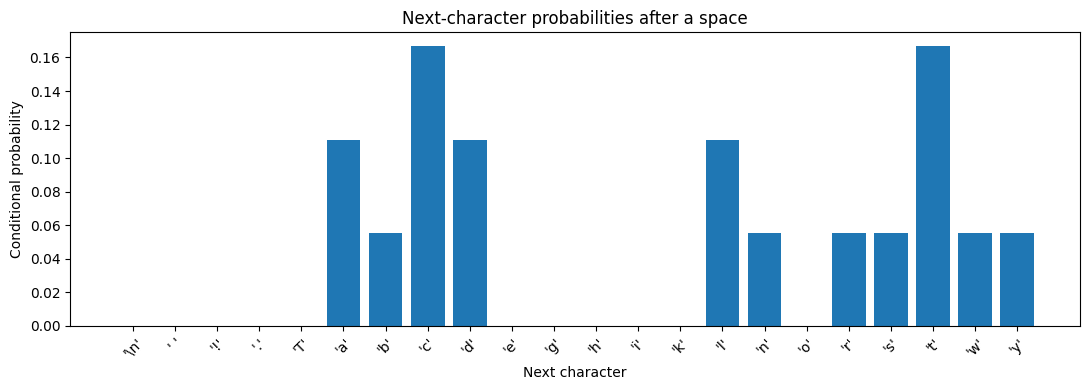

In [17]:
import matplotlib.pyplot as plt  # noqa: I001


previous_character_to_plot = " "
probabilities_after_space = bigram_probability_table[
    character_to_id[previous_character_to_plot]
]
plot_labels = [repr(character) for character in character_vocabulary]

plt.figure(figsize=(11, 4))
plt.bar(plot_labels, probabilities_after_space)
plt.xlabel("Next character")
plt.ylabel("Conditional probability")
plt.title("Next-character probabilities after a space")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize the Full Probability Table

Every horizontal heatmap row is a separate conditional distribution over next characters.


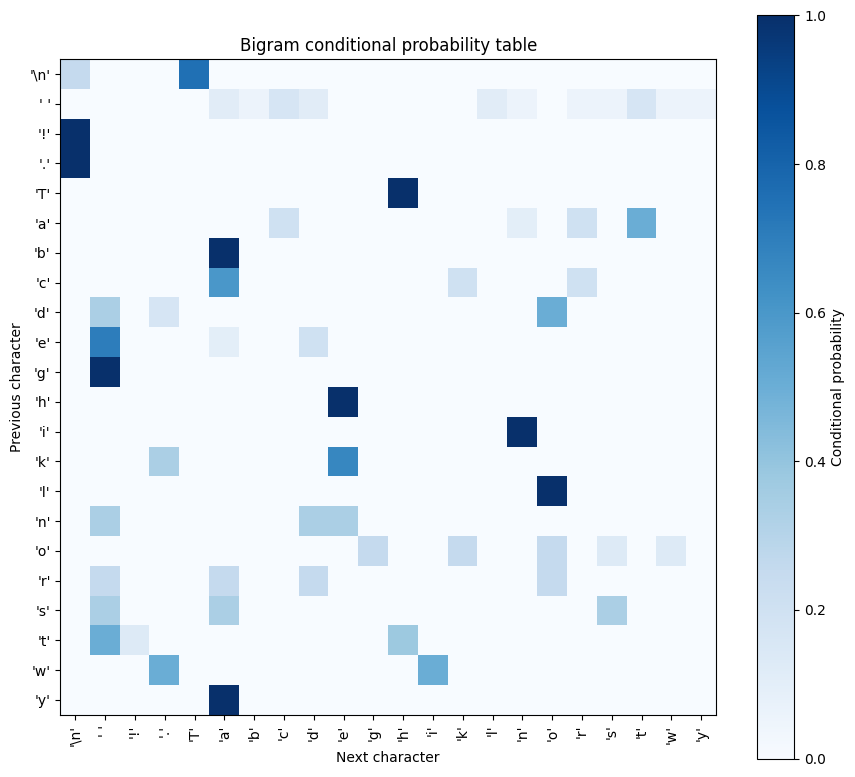

In [18]:
tick_positions = list(range(vocabulary_size))
tick_labels = [repr(character) for character in character_vocabulary]

plt.figure(figsize=(9, 8))
plt.imshow(bigram_probability_table, aspect="equal", cmap="Blues", vmin=0, vmax=1)
plt.xlabel("Next character")
plt.ylabel("Previous character")
plt.title("Bigram conditional probability table")
plt.xticks(tick_positions, tick_labels, rotation=90)
plt.yticks(tick_positions, tick_labels)
plt.colorbar(label="Conditional probability")
plt.tight_layout()
plt.show()

The probability heatmap differs from a count heatmap because each row has been rescaled independently.

A rare previous character can therefore have a probability-one transition even when that pair appeared only once.


## Sample From One Row

Sampling chooses token IDs according to the probabilities in the selected row.

A fixed seed keeps the stored sample deterministic.


In [19]:
import random  # noqa: I001


RANDOM_SEED = 15


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    assert_valid_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]


random_generator = random.Random(RANDOM_SEED)
probabilities_after_c = bigram_probability_table[character_to_id["c"]]
sampled_characters = [
    id_to_character[sample_token_id(probabilities_after_c, random_generator)]
    for _ in range(20)
]

print("Samples after 'c':", [repr(character) for character in sampled_characters])
assert all(
    probabilities_after_c[character_to_id[character]] > 0
    for character in sampled_characters
)

Samples after 'c': ["'r'", "'a'", "'k'", "'a'", "'r'", "'a'", "'r'", "'k'", "'r'", "'r'", "'a'", "'a'", "'k'", "'a'", "'a'", "'a'", "'r'", "'r'", "'k'", "'a'"]


The samples can contain only characters with positive probability in the row for `"c"`.


## Find the Most Likely Next Character

Taking the largest probability provides a deterministic summary of a row rather than a random sample.


In [20]:
def most_likely_token_id(probabilities: list[float]) -> int:
    assert_valid_probability_distribution(probabilities)
    return max(range(len(probabilities)), key=probabilities.__getitem__)


for previous_character in ["T", "h", "e", " ", "c", "a", "."]:
    row = bigram_probability_table[character_to_id[previous_character]]
    best_id = most_likely_token_id(row)
    print(
        f"after {previous_character!r:>3}: {id_to_character[best_id]!r:>4} "
        f"with probability {row[best_id]:.6f}"
    )

after 'T':  'h' with probability 1.000000
after 'h':  'e' with probability 1.000000
after 'e':  ' ' with probability 0.700000
after ' ':  'c' with probability 0.166667
after 'c':  'a' with probability 0.600000
after 'a':  't' with probability 0.500000
after '.': '\n' with probability 1.000000


## Package the Probability Table as a Model

The model uses the final input token ID to select one row.

An empty or invalid context uses the deliberate fallback distribution.


In [21]:
class BigramProbabilityTableModel:
    def __init__(
        self,
        probability_table: list[list[float]],
        fallback_probabilities: list[float],
    ):
        assert_valid_probability_distribution(fallback_probabilities)
        for row in probability_table:
            assert_valid_probability_distribution(row)
        self.probability_table = probability_table
        self.fallback_probabilities = fallback_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        if not input_token_ids:
            return self.fallback_probabilities

        previous_token_id = input_token_ids[-1]
        if not 0 <= previous_token_id < len(self.probability_table):
            return self.fallback_probabilities
        return self.probability_table[previous_token_id]


bigram_model = BigramProbabilityTableModel(
    bigram_probability_table,
    unigram_fallback_probabilities,
)

## Verify the Model Uses Only the Final Token

Two contexts ending in `"c"` must select the same probability row.


In [22]:
contexts = ["The c", "abc"]
predictions = []

for context in contexts:
    context_ids = encode_characters(context, character_to_id)
    probabilities = bigram_model.predict_next_token_probabilities(context_ids)
    predictions.append(probabilities)
    best_id = most_likely_token_id(probabilities)
    print(
        f"context {context!r} uses {context[-1]!r}; "
        f"best next character is {id_to_character[best_id]!r}"
    )

assert predictions[0] == predictions[1]

context 'The c' uses 'c'; best next character is 'a'
context 'abc' uses 'c'; best next character is 'a'


This equality is expected behavior for a bigram model rather than a bug.

The model has no way to distinguish longer contexts that share the same final token.


## Generate From the Probability Table

Each sampled character becomes the previous character used to choose the next row.


In [23]:
def generate_bigram_text(
    model: BigramProbabilityTableModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt
    for _ in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(input_ids)
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text


generated_text = generate_bigram_text(
    bigram_model,
    prompt="T",
    number_of_new_characters=160,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print(generated_text)
print()
print(repr(generated_text))

Theacr thed dok.
The wind.
Thedoked.



The log arooke yan t w.

The losss athe log t!
The acat doookedow.
The crathe ne acrd t!
The t!
The t roooosandog loosath

'Theacr thed dok.\nThe wind.\nThedoked.\n\n\n\nThe log arooke yan t w.\n\nThe losss athe log t!\nThe acat doookedow.\nThe crathe ne acrd t!\nThe t!\nThe t roooosandog loosath'


The output reflects observed local transitions, but it remains globally incoherent because only one previous character influences each prediction.


## Trace a Short Generation

The trace exposes the selected row, sampled character, and probability at each step.


In [24]:
def trace_bigram_generation(
    model: BigramProbabilityTableModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    random_generator = random.Random(random_seed)
    generated_text = prompt

    for step in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(input_ids)
        next_id = sample_token_id(probabilities, random_generator)
        next_character = id_to_character[next_id]
        previous_display = repr(generated_text[-1]) if generated_text else "<empty>"
        print(
            f"step {step + 1:>2}: after {previous_display:>8}, sampled "
            f"{next_character!r:>6} with probability {probabilities[next_id]:.6f}"
        )
        generated_text += next_character
    return generated_text


traced_text = trace_bigram_generation(
    bigram_model,
    prompt="T",
    number_of_new_characters=12,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)
print("Final traced text:", repr(traced_text))

step  1: after      'T', sampled    'h' with probability 1.000000
step  2: after      'h', sampled    'e' with probability 1.000000
step  3: after      'e', sampled    'a' with probability 0.100000
step  4: after      'a', sampled    'c' with probability 0.200000
step  5: after      'c', sampled    'r' with probability 0.200000
step  6: after      'r', sampled    ' ' with probability 0.250000
step  7: after      ' ', sampled    't' with probability 0.166667
step  8: after      't', sampled    'h' with probability 0.375000
step  9: after      'h', sampled    'e' with probability 1.000000
step 10: after      'e', sampled    'd' with probability 0.200000
step 11: after      'd', sampled    ' ' with probability 0.333333
step 12: after      ' ', sampled    'd' with probability 0.111111
Final traced text: 'Theacr thed d'


## Count Zero-Probability Cells

Observed rows remain unsmoothed, so transitions absent from the fixture retain probability zero.


In [25]:
zero_probability_cell_count = sum(
    probability == 0 for row in bigram_probability_table for probability in row
)
total_cell_count = vocabulary_size * vocabulary_size

print("Total cells:", total_cell_count)
print("Zero-probability cells:", zero_probability_cell_count)
print("Zero-probability fraction:", zero_probability_cell_count / total_cell_count)

Total cells: 484
Zero-probability cells: 427
Zero-probability fraction: 0.8822314049586777


A zero probability means that this transition was unobserved under this previous-character condition.

It does not establish impossibility in real language.

The next chapter will introduce smoothing to address this brittleness directly.


## Complete Probability-Table Pipeline

The final cell rebuilds the model and verifies the key invariants in one place.


In [26]:
final_vocabulary, final_character_to_id, final_id_to_character = (
    build_character_mappings(prepared_text)
)
final_token_ids = encode_characters(prepared_text, final_character_to_id)
final_count_table = build_bigram_count_table(
    final_token_ids,
    len(final_vocabulary),
)
final_unigram_counts = count_token_ids(final_token_ids, len(final_vocabulary))
final_fallback = normalize_count_row(final_unigram_counts)
final_probability_table, final_fallback_rows = count_table_to_probability_table(
    final_count_table, final_fallback
)

for row in final_probability_table:
    assert_valid_probability_distribution(row)

final_model = BigramProbabilityTableModel(
    final_probability_table,
    final_fallback,
)
final_generated_text = generate_bigram_text(
    final_model,
    prompt="T",
    number_of_new_characters=80,
    character_to_id=final_character_to_id,
    id_to_character=final_id_to_character,
    random_seed=RANDOM_SEED,
)

assert set(final_generated_text).issubset(set(final_vocabulary))
print("Vocabulary size:", len(final_vocabulary))
print("Count table total:", sum_count_table(final_count_table))
print("Fallback row count:", len(final_fallback_rows))
print("Generated text:", repr(final_generated_text))

Vocabulary size: 22
Count table total: 105
Fallback row count: 0
Generated text: 'Theacr thed dok.\nThe wind.\nThedoked.\n\n\n\nThe log arooke yan t w.\n\nThe losss athe l'


## Common Mistakes

- Normalize each row separately rather than dividing by the total count of the whole table.

- Do not pass raw counts to code that expects probabilities.

- Validate every probability row before sampling.

- Expose zero rows instead of allowing division by zero.

- Keep fallback separate from smoothing.

- Interpret probability zero as unobserved in this training data rather than impossible in language.

- Remember that a bigram model ignores every prompt token except the final one.


## Takeaways

Row normalization divides each transition count by the total count for its previous-token row.

The result is a conditional probability table representing $P(\text{next token}\mid\text{previous token})$.

Every returned row must sum to one before it can be used for sampling.

A deliberate fallback handles a row with no outgoing evidence, while observed rows remain unsmoothed and can contain many zeros.

The next chapter will introduce smoothing so unobserved transitions are not assigned probability zero so aggressively.
